# 01. 데이터 가져오기

In [4]:
import pandas as pd

file_path = '../../data/Imputation_Test.xlsx'
sheet_index = 0 
test_data = pd.read_excel(file_path, sheet_name=sheet_index)

---

# 02. 데이터 형태 정리 및 독립변수 분리

In [5]:
df = test_data.copy()
df = df.iloc[:, 3:]
df.columns = df.iloc[1]
df = df.drop([0, 1]).reset_index(drop=True)

data = df.iloc[:, :53] #독립변수만 분리

selected_cols = [
    'Index', 'Class1', 'Class2', 'CaO', 'Al2O3', 'SiO2', 'Fe2O3', 'SO3', 'MgO', 'etc',
    'FM', 'MeanV', 'Density', 'Blain', 'HG', 'AG', 'DG', 'Gyp_per', 'WC_per'
]
data = data[selected_cols]  # 필요한 컬럼 리스트 지정

cols_to_convert = data.columns[3:]  # Index, Class1, Class2 제외한 칼럼들을 수치형 컬럼으로 변환
data[cols_to_convert] = data[cols_to_convert].apply(pd.to_numeric, errors='coerce')

In [6]:
data.tail(50)

1,Index,Class1,Class2,CaO,Al2O3,SiO2,Fe2O3,SO3,MgO,etc,FM,MeanV,Density,Blain,HG,AG,DG,Gyp_per,WC_per
401,231213-36,세아,시멘트,46.65,30.73,7.78,0.56,4.700,7.60,1.980,2.84,5.120,2.930,6152.000,NaN,NaN,NaN,25.0,0.4
402,221108-02,현대,시멘트,50.43,27.52,11.81,1.51,1.040,5.04,2.650,2.70,9.854,2.936,5078.000,NaN,NaN,NaN,20.0,0.5
403,240612-09,세아,시멘트,47.46,27.91,8.34,0.68,4.120,6.10,5.390,3.23,7.394,2.970,5998.000,NaN,NaN,NaN,25.0,0.4
404,230720-19,현대,시멘트,49.51,23.98,9.87,7.26,0.400,4.66,4.320,4.40,10.746,2.905,5953.000,NaN,NaN,NaN,30.0,0.4
405,240812-21,세아,시멘트,47.46,27.91,8.34,0.68,4.120,6.10,5.390,3.23,7.394,2.970,5998.000,NaN,NaN,NaN,25.0,0.5
406,240206-QC,세아,시멘트,47.46,27.91,8.34,0.68,4.120,6.10,5.390,3.23,10.655,2.970,5998.000,NaN,NaN,NaN,25.0,0.5
407,240206-SS50-QC50,세아,시멘트,47.46,27.91,8.34,0.68,4.120,6.10,5.390,3.23,10.655,2.970,5998.000,NaN,NaN,NaN,25.0,0.5
408,240602-06,현대,시멘트,53.40,25.21,10.87,3.19,0.530,3.70,3.100,4.20,9.452,3.100,5991.000,NaN,NaN,NaN,25.0,0.4
409,210701-01,세아,시멘트,49.07,29.81,7.83,1.94,3.440,6.36,1.550,3.18,5.450,2.910,5994.000,NaN,NaN,NaN,25.0,0.5
410,250304-02,세아,시멘트,49.10,27.28,11.62,1.18,4.290,5.42,1.110,3.36,12.260,2.970,5.858,NaN,NaN,NaN,25.0,0.5


In [7]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 451 entries, 0 to 450
Data columns (total 19 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   Index    451 non-null    object 
 1   Class1   451 non-null    object 
 2   Class2   451 non-null    object 
 3   CaO      451 non-null    float64
 4   Al2O3    451 non-null    float64
 5   SiO2     451 non-null    float64
 6   Fe2O3    451 non-null    float64
 7   SO3      451 non-null    float64
 8   MgO      451 non-null    float64
 9   etc      451 non-null    float64
 10  FM       441 non-null    float64
 11  MeanV    441 non-null    float64
 12  Density  441 non-null    float64
 13  Blain    441 non-null    float64
 14  HG       441 non-null    float64
 15  AG       441 non-null    float64
 16  DG       441 non-null    float64
 17  Gyp_per  441 non-null    float64
 18  WC_per   441 non-null    float64
dtypes: float64(16), object(3)
memory usage: 67.1+ KB


---

# 03. 1D-CNN을 활용한 결측치 대체

#### 01) 기준이 되는 mean 데이터 생성

In [8]:
mean = data.copy()
mean = mean.fillna(mean.mean(numeric_only=True))
mean

1,Index,Class1,Class2,CaO,Al2O3,SiO2,Fe2O3,SO3,MgO,etc,FM,MeanV,Density,Blain,HG,AG,DG,Gyp_per,WC_per
0,231023-02,현대,시멘트,50.07,29.69,9.64,2.75,0.70,3.73,3.42,3.500000,7.394,3.100,6286.0,1.0,0.0,0.0,20.0,0.50
1,230411-01,세아,시멘트,46.65,30.73,7.78,0.56,4.70,7.60,1.98,2.840000,5.120,2.930,6152.0,1.0,0.0,0.0,25.0,0.50
2,230406-02,세아,기포콘크리트,46.65,30.73,7.78,0.56,4.70,7.60,1.98,2.840000,5.120,2.930,6152.0,1.0,0.0,0.0,25.0,0.35
3,230316-05,세아,기포콘크리트,46.65,30.73,7.78,0.56,4.70,7.60,1.98,2.840000,5.120,2.930,6152.0,1.0,0.0,0.0,25.0,0.35
4,210713-03,세아,시멘트,49.07,29.81,7.83,1.94,3.44,6.36,1.55,3.180000,5.450,2.910,5994.0,1.0,0.0,0.0,25.0,0.50
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
446,210624-04,세아,시멘트,49.07,29.81,7.83,1.94,3.44,6.36,1.55,3.312268,5.450,2.910,5994.0,1.0,0.0,0.0,25.0,0.50
447,221206-08,현대,시멘트,51.65,28.93,11.68,0.96,0.64,3.14,3.00,3.312268,8.221,2.941,6042.0,0.0,0.0,1.0,40.0,0.50
448,240710-02,현대,시멘트,49.11,25.67,9.04,5.37,0.46,6.52,3.83,3.312268,7.526,3.000,5987.0,1.0,0.0,0.0,25.0,0.50
449,210701-02,세아,시멘트,49.07,29.81,7.83,1.94,3.44,6.36,1.55,3.312268,5.450,2.910,5994.0,1.0,0.0,0.0,25.0,0.50


In [9]:
mean.to_excel('mean.xlsx', index=False)  # index=False: 인덱스 열 저장 안 함

#### 02) 결측치 대체 진행 (1회 반복)

In [24]:
original_nan_idx = {col: data[data[col].isna()].index.tolist() for col in target_cols}
original_nan_idx

{'FM': [441, 442, 443, 444, 445, 446, 447, 448, 449, 450],
 'MeanV': [431, 432, 433, 434, 435, 436, 437, 438, 439, 440],
 'Density': [421, 422, 423, 424, 425, 426, 427, 428, 429, 430],
 'Blain': [411, 412, 413, 414, 415, 416, 417, 418, 419, 420],
 'HG': [401, 402, 403, 404, 405, 406, 407, 408, 409, 410],
 'AG': [401, 402, 403, 404, 405, 406, 407, 408, 409, 410],
 'DG': [401, 402, 403, 404, 405, 406, 407, 408, 409, 410],
 'Gyp_per': [391, 392, 393, 394, 395, 396, 397, 398, 399, 400],
 'WC_per': [381, 382, 383, 384, 385, 386, 387, 388, 389, 390]}

In [25]:
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from sklearn.preprocessing import StandardScaler

# 1. 타겟 컬럼 목록
target_cols = ['FM', 'MeanV', 'Density', 'Blain', 'HG', 'AG', 'DG', 'Gyp_per', 'WC_per']

# 2. 수치형 컬럼만 사용
num_cols = mean.select_dtypes(include='float64').columns.tolist()

# 3. 원래 결측치 위치 저장
original_nan_idx = {col: data[data[col].isna()].index.tolist() for col in target_cols}

# 4. PyTorch Dataset
class ImputationDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.tensor(X.values, dtype=torch.float32)
        self.y = torch.tensor(y.values, dtype=torch.float32)

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        return self.X[idx].unsqueeze(0), self.y[idx]  # shape: (C, L), scalar

# 5. 1D-CNN 모델 정의
class CNN1D(nn.Module):
    def __init__(self, input_length):
        super(CNN1D, self).__init__()
        self.model = nn.Sequential(
            nn.Conv1d(1, 16, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.Conv1d(16, 8, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.Flatten(),
            nn.Linear(8 * input_length, 1)
        )

    def forward(self, x):
        return self.model(x).squeeze(1)

# 6. 결측치 대체 루프
df_filled = mean.copy()
scaler = StandardScaler()

for target in target_cols:
    print(f"\n Now imputing: {target}")

    # 6-1. 원래 결측치 위치 다시 NaN으로 복원
    df_filled.loc[original_nan_idx[target], target] = np.nan

    # 6-2. 정규화 (NaN 행 제외 후 fit)
    df_scaled = df_filled.copy()
    df_scaled[num_cols] = df_scaled[num_cols].apply(pd.to_numeric, errors='coerce')
    scaler.fit(df_scaled[num_cols].dropna())
    df_scaled[num_cols] = scaler.transform(df_scaled[num_cols])

    # 6-3. 학습/테스트 데이터 구성
    input_cols = [col for col in num_cols if col != target]
    mask_train = df_scaled[target].notna()
    mask_test = df_scaled[target].isna()

    X_train = df_scaled.loc[mask_train, input_cols]
    y_train = df_scaled.loc[mask_train, target]
    X_test = df_scaled.loc[mask_test, input_cols]

    # 6-4. X_train 내 NaN 제거
    mask_valid = ~X_train.isna().any(axis=1)
    X_train = X_train[mask_valid]
    y_train = y_train[mask_valid]

    # 6-5. Dataset & DataLoader
    train_dataset = ImputationDataset(X_train, y_train)
    train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)

    # 6-6. 모델 학습
    model = CNN1D(input_length=len(input_cols))
    criterion = nn.MSELoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

    for epoch in range(100):
        model.train()
        for xb, yb in train_loader:
            pred = model(xb)
            loss = criterion(pred, yb)
            if torch.isnan(loss):
                print(f"⚠️ NaN loss 발생: {target}")
                break
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

    # 6-7. 예측 및 결측치 채우기
    model.eval()
    with torch.no_grad():
        X_test_tensor = torch.tensor(X_test.values, dtype=torch.float32).unsqueeze(1)
        y_pred = model(X_test_tensor).numpy()

    df_scaled.loc[mask_test, target] = y_pred

    # 6-8. 역정규화 후 해당 열만 반영
    df_scaled[num_cols] = scaler.inverse_transform(df_scaled[num_cols])
    df_filled[target] = df_scaled[target]

# ✅ 최종 결과 저장
result_df = df_filled.copy()



 Now imputing: FM

 Now imputing: MeanV

 Now imputing: Density

 Now imputing: Blain

 Now imputing: HG

 Now imputing: AG

 Now imputing: DG

 Now imputing: Gyp_per

 Now imputing: WC_per


In [26]:
original_nan_idx

{'FM': [441, 442, 443, 444, 445, 446, 447, 448, 449, 450],
 'MeanV': [431, 432, 433, 434, 435, 436, 437, 438, 439, 440],
 'Density': [421, 422, 423, 424, 425, 426, 427, 428, 429, 430],
 'Blain': [411, 412, 413, 414, 415, 416, 417, 418, 419, 420],
 'HG': [401, 402, 403, 404, 405, 406, 407, 408, 409, 410],
 'AG': [401, 402, 403, 404, 405, 406, 407, 408, 409, 410],
 'DG': [401, 402, 403, 404, 405, 406, 407, 408, 409, 410],
 'Gyp_per': [391, 392, 393, 394, 395, 396, 397, 398, 399, 400],
 'WC_per': [381, 382, 383, 384, 385, 386, 387, 388, 389, 390]}

In [27]:
result_df

1,Index,Class1,Class2,CaO,Al2O3,SiO2,Fe2O3,SO3,MgO,etc,FM,MeanV,Density,Blain,HG,AG,DG,Gyp_per,WC_per
0,231023-02,현대,시멘트,50.07,29.69,9.64,2.75,0.70,3.73,3.42,3.500000,7.394,3.100,6286.0,1.0,0.0,0.0,20.0,0.50
1,230411-01,세아,시멘트,46.65,30.73,7.78,0.56,4.70,7.60,1.98,2.840000,5.120,2.930,6152.0,1.0,0.0,0.0,25.0,0.50
2,230406-02,세아,기포콘크리트,46.65,30.73,7.78,0.56,4.70,7.60,1.98,2.840000,5.120,2.930,6152.0,1.0,0.0,0.0,25.0,0.35
3,230316-05,세아,기포콘크리트,46.65,30.73,7.78,0.56,4.70,7.60,1.98,2.840000,5.120,2.930,6152.0,1.0,0.0,0.0,25.0,0.35
4,210713-03,세아,시멘트,49.07,29.81,7.83,1.94,3.44,6.36,1.55,3.180000,5.450,2.910,5994.0,1.0,0.0,0.0,25.0,0.50
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
446,210624-04,세아,시멘트,49.07,29.81,7.83,1.94,3.44,6.36,1.55,3.151003,5.450,2.910,5994.0,1.0,0.0,0.0,25.0,0.50
447,221206-08,현대,시멘트,51.65,28.93,11.68,0.96,0.64,3.14,3.00,4.311342,8.221,2.941,6042.0,0.0,0.0,1.0,40.0,0.50
448,240710-02,현대,시멘트,49.11,25.67,9.04,5.37,0.46,6.52,3.83,4.351390,7.526,3.000,5987.0,1.0,0.0,0.0,25.0,0.50
449,210701-02,세아,시멘트,49.07,29.81,7.83,1.94,3.44,6.36,1.55,3.151003,5.450,2.910,5994.0,1.0,0.0,0.0,25.0,0.50


In [28]:
mean

1,Index,Class1,Class2,CaO,Al2O3,SiO2,Fe2O3,SO3,MgO,etc,FM,MeanV,Density,Blain,HG,AG,DG,Gyp_per,WC_per
0,231023-02,현대,시멘트,50.07,29.69,9.64,2.75,0.70,3.73,3.42,3.500000,7.394,3.100,6286.0,1.0,0.0,0.0,20.0,0.50
1,230411-01,세아,시멘트,46.65,30.73,7.78,0.56,4.70,7.60,1.98,2.840000,5.120,2.930,6152.0,1.0,0.0,0.0,25.0,0.50
2,230406-02,세아,기포콘크리트,46.65,30.73,7.78,0.56,4.70,7.60,1.98,2.840000,5.120,2.930,6152.0,1.0,0.0,0.0,25.0,0.35
3,230316-05,세아,기포콘크리트,46.65,30.73,7.78,0.56,4.70,7.60,1.98,2.840000,5.120,2.930,6152.0,1.0,0.0,0.0,25.0,0.35
4,210713-03,세아,시멘트,49.07,29.81,7.83,1.94,3.44,6.36,1.55,3.180000,5.450,2.910,5994.0,1.0,0.0,0.0,25.0,0.50
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
446,210624-04,세아,시멘트,49.07,29.81,7.83,1.94,3.44,6.36,1.55,3.312268,5.450,2.910,5994.0,1.0,0.0,0.0,25.0,0.50
447,221206-08,현대,시멘트,51.65,28.93,11.68,0.96,0.64,3.14,3.00,3.312268,8.221,2.941,6042.0,0.0,0.0,1.0,40.0,0.50
448,240710-02,현대,시멘트,49.11,25.67,9.04,5.37,0.46,6.52,3.83,3.312268,7.526,3.000,5987.0,1.0,0.0,0.0,25.0,0.50
449,210701-02,세아,시멘트,49.07,29.81,7.83,1.94,3.44,6.36,1.55,3.312268,5.450,2.910,5994.0,1.0,0.0,0.0,25.0,0.50


#### 03) 10회 반복

In [8]:
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from sklearn.preprocessing import StandardScaler

# 설정
target_cols = ['FM', 'MeanV', 'Density', 'Blain', 'HG', 'AG', 'DG', 'Gyp_per', 'WC_per']
num_cols = mean.select_dtypes(include='float64').columns.tolist()
original_nan_idx = {col: data[data[col].isna()].index.tolist() for col in target_cols}
print(original_nan_idx)
n_iter = 10  # 반복 횟수

# PyTorch Dataset
class ImputationDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.tensor(X.values, dtype=torch.float32)
        self.y = torch.tensor(y.values, dtype=torch.float32)

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        return self.X[idx].unsqueeze(0), self.y[idx]

# 1D-CNN 정의
class CNN1D(nn.Module):
    def __init__(self, input_length):
        super(CNN1D, self).__init__()
        self.model = nn.Sequential(
            nn.Conv1d(1, 16, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.Conv1d(16, 8, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.Flatten(),
            nn.Linear(8 * input_length, 1)
        )

    def forward(self, x):
        return self.model(x).squeeze(1)

# 평균으로 채운 데이터 복사 (한 번만)
df_filled = mean.copy()

# 결과 저장용
results = {col: pd.DataFrame(index=original_nan_idx[col]) for col in target_cols}

{'FM': [441, 442, 443, 444, 445, 446, 447, 448, 449, 450], 'MeanV': [431, 432, 433, 434, 435, 436, 437, 438, 439, 440], 'Density': [421, 422, 423, 424, 425, 426, 427, 428, 429, 430], 'Blain': [411, 412, 413, 414, 415, 416, 417, 418, 419, 420], 'HG': [401, 402, 403, 404, 405, 406, 407, 408, 409, 410], 'AG': [401, 402, 403, 404, 405, 406, 407, 408, 409, 410], 'DG': [401, 402, 403, 404, 405, 406, 407, 408, 409, 410], 'Gyp_per': [391, 392, 393, 394, 395, 396, 397, 398, 399, 400], 'WC_per': [381, 382, 383, 384, 385, 386, 387, 388, 389, 390]}


In [9]:
# 🔁 연쇄적 반복 시작
for iter_idx in range(n_iter):
    print(f"\n================== Iteration {iter_idx+1} ==================")
    scaler = StandardScaler()

    for target in target_cols:
        print(f"\n Now imputing: {target}")

        # 원래 결측치 위치 복원
        df_filled.loc[original_nan_idx[target], target] = np.nan

        # 정규화
        df_scaled = df_filled.copy()
        df_scaled[num_cols] = df_scaled[num_cols].apply(pd.to_numeric, errors='coerce')
        scaler.fit(df_scaled[num_cols].dropna())
        df_scaled[num_cols] = scaler.transform(df_scaled[num_cols])

        input_cols = [col for col in num_cols if col != target]
        mask_train = df_scaled[target].notna()
        mask_test = df_scaled[target].isna()

        X_train = df_scaled.loc[mask_train, input_cols]
        y_train = df_scaled.loc[mask_train, target]
        X_test = df_scaled.loc[mask_test, input_cols]

        mask_valid = ~X_train.isna().any(axis=1)
        X_train = X_train[mask_valid]
        y_train = y_train[mask_valid]

        train_dataset = ImputationDataset(X_train, y_train)
        train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)

        model = CNN1D(input_length=len(input_cols))
        criterion = nn.MSELoss()
        optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

        for epoch in range(100):
            model.train()
            for xb, yb in train_loader:
                pred = model(xb)
                loss = criterion(pred, yb)
                if torch.isnan(loss):
                    print(f"⚠️ NaN loss 발생: {target}")
                    break
                optimizer.zero_grad()
                loss.backward()
                optimizer.step()

        # 예측 및 누적 반영
        model.eval()
        with torch.no_grad():
            X_test_tensor = torch.tensor(X_test.values, dtype=torch.float32).unsqueeze(1)
            y_pred_scaled = model(X_test_tensor).numpy()

        # 🔁 스케일 복구 (inverse transform)
        target_idx = num_cols.index(target)
        target_mean = scaler.mean_[target_idx]
        target_scale = scaler.scale_[target_idx]
        y_pred = y_pred_scaled * target_scale + target_mean  # 복구된 원래 스케일 값

        # 예측 결과 저장 및 누적 반영
        results[target][f"iter{iter_idx+1}"] = pd.Series(y_pred, index=original_nan_idx[target])
        df_filled.loc[original_nan_idx[target], target] = y_pred  # ⬅️ 누적 대체 핵심

# 🔚 마지막 반복 결과 반영
result_df = df_filled.copy()


================== Iteration 1 ==================

 Now imputing: FM

 Now imputing: MeanV

 Now imputing: Density

 Now imputing: Blain

 Now imputing: HG

 Now imputing: AG

 Now imputing: DG

 Now imputing: Gyp_per

 Now imputing: WC_per

================== Iteration 2 ==================

 Now imputing: FM

 Now imputing: MeanV

 Now imputing: Density

 Now imputing: Blain

 Now imputing: HG

 Now imputing: AG

 Now imputing: DG

 Now imputing: Gyp_per

 Now imputing: WC_per

================== Iteration 3 ==================

 Now imputing: FM

 Now imputing: MeanV

 Now imputing: Density

 Now imputing: Blain

 Now imputing: HG

 Now imputing: AG

 Now imputing: DG

 Now imputing: Gyp_per

 Now imputing: WC_per

================== Iteration 4 ==================

 Now imputing: FM

 Now imputing: MeanV

 Now imputing: Density

 Now imputing: Blain

 Now imputing: HG

 Now imputing: AG

 Now imputing: DG

 Now imputing: Gyp_per

 Now imputing: WC_per

================== Iteration 5 

In [10]:
result_df

1,Index,Class1,Class2,CaO,Al2O3,SiO2,Fe2O3,SO3,MgO,etc,FM,MeanV,Density,Blain,HG,AG,DG,Gyp_per,WC_per
0,231023-02,현대,시멘트,50.07,29.69,9.64,2.75,0.70,3.73,3.42,3.500000,7.394,3.100,6286.0,1.0,0.0,0.0,20.0,0.50
1,230411-01,세아,시멘트,46.65,30.73,7.78,0.56,4.70,7.60,1.98,2.840000,5.120,2.930,6152.0,1.0,0.0,0.0,25.0,0.50
2,230406-02,세아,기포콘크리트,46.65,30.73,7.78,0.56,4.70,7.60,1.98,2.840000,5.120,2.930,6152.0,1.0,0.0,0.0,25.0,0.35
3,230316-05,세아,기포콘크리트,46.65,30.73,7.78,0.56,4.70,7.60,1.98,2.840000,5.120,2.930,6152.0,1.0,0.0,0.0,25.0,0.35
4,210713-03,세아,시멘트,49.07,29.81,7.83,1.94,3.44,6.36,1.55,3.180000,5.450,2.910,5994.0,1.0,0.0,0.0,25.0,0.50
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
446,210624-04,세아,시멘트,49.07,29.81,7.83,1.94,3.44,6.36,1.55,3.118926,5.450,2.910,5994.0,1.0,0.0,0.0,25.0,0.50
447,221206-08,현대,시멘트,51.65,28.93,11.68,0.96,0.64,3.14,3.00,4.229805,8.221,2.941,6042.0,0.0,0.0,1.0,40.0,0.50
448,240710-02,현대,시멘트,49.11,25.67,9.04,5.37,0.46,6.52,3.83,4.305715,7.526,3.000,5987.0,1.0,0.0,0.0,25.0,0.50
449,210701-02,세아,시멘트,49.07,29.81,7.83,1.94,3.44,6.36,1.55,3.118926,5.450,2.910,5994.0,1.0,0.0,0.0,25.0,0.50


---

# 04. 최종 오차 예측

#### 01) label_data(정답 데이터) 저장

In [13]:
# label값이 저장되어있는 데이터 불러오기 (초기 코드는 동일)
file_path = '../../data/Imputation_Test.xlsx'
sheet_index = 1 
test_data = pd.read_excel(file_path, sheet_name=sheet_index)

df = test_data.copy()
df = df.iloc[:, 3:]
df.columns = df.iloc[1]
df = df.drop([0, 1]).reset_index(drop=True)

data = df.iloc[:, :53] #독립변수만 분리

selected_cols = [
    'Index', 'Class1', 'Class2', 'CaO', 'Al2O3', 'SiO2', 'Fe2O3', 'SO3', 'MgO', 'etc',
    'FM', 'MeanV', 'Density', 'Blain', 'HG', 'AG', 'DG', 'Gyp_per', 'WC_per'
]
data = data[selected_cols]  # 필요한 컬럼 리스트 지정

cols_to_convert = data.columns[3:]  # Index, Class1, Class2 제외한 칼럼들을 수치형 컬럼으로 변환
data[cols_to_convert] = data[cols_to_convert].apply(pd.to_numeric, errors='coerce')

label_data = data.copy()
label_data

1,Index,Class1,Class2,CaO,Al2O3,SiO2,Fe2O3,SO3,MgO,etc,FM,MeanV,Density,Blain,HG,AG,DG,Gyp_per,WC_per
0,231023-02,현대,시멘트,50.07,29.69,9.64,2.75,0.70,3.73,3.42,3.50,7.394,3.100,6286.0,1,0,0,20,0.50
1,230411-01,세아,시멘트,46.65,30.73,7.78,0.56,4.70,7.60,1.98,2.84,5.120,2.930,6152.0,1,0,0,25,0.50
2,230406-02,세아,기포콘크리트,46.65,30.73,7.78,0.56,4.70,7.60,1.98,2.84,5.120,2.930,6152.0,1,0,0,25,0.35
3,230316-05,세아,기포콘크리트,46.65,30.73,7.78,0.56,4.70,7.60,1.98,2.84,5.120,2.930,6152.0,1,0,0,25,0.35
4,210713-03,세아,시멘트,49.07,29.81,7.83,1.94,3.44,6.36,1.55,3.18,5.450,2.910,5994.0,1,0,0,25,0.50
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
446,210624-04,세아,시멘트,49.07,29.81,7.83,1.94,3.44,6.36,1.55,3.18,5.450,2.910,5994.0,1,0,0,25,0.50
447,221206-08,현대,시멘트,51.65,28.93,11.68,0.96,0.64,3.14,3.00,4.20,8.221,2.941,6042.0,0,0,1,40,0.50
448,240710-02,현대,시멘트,49.11,25.67,9.04,5.37,0.46,6.52,3.83,4.30,7.526,3.000,5987.0,1,0,0,25,0.50
449,210701-02,세아,시멘트,49.07,29.81,7.83,1.94,3.44,6.36,1.55,3.18,5.450,2.910,5994.0,1,0,0,25,0.50


#### 02) 오차 ( |예측값-실제값| ) 확인

In [40]:
# 결과를 누적할 리스트
records = []

# 타겟 컬럼별로 결측치 인덱스에 대해 오차 기록
for col in target_cols:
    missing_idx = original_nan_idx[col]
    
    for idx in missing_idx:
        true_val = label_data.loc[idx, col]
        pred_val = result_df.loc[idx, col]
        error = abs(pred_val - true_val)
        
        records.append({
            'Column': col,
            'Index': idx,
            'True Value': true_val,
            'Predicted Value': pred_val,
            'Error': error
        })

error_df = pd.DataFrame(records)

In [41]:
error_df
# error_df.to_csv("cnn_10_error.csv", index=False, encoding='utf-8-sig')

,Column,Index,True Value,Predicted Value,Error
0,FM,441,3.36,2.243160,1.116840
1,FM,442,4.40,4.378715,0.021285
2,FM,443,3.18,3.114911,0.065089
3,FM,444,4.40,4.241379,0.158621
4,FM,445,2.84,2.836023,0.003977
...,...,...,...,...,...
85,WC_per,386,0.50,0.419144,0.080856
86,WC_per,387,0.40,0.415995,0.015995
87,WC_per,388,0.40,0.415995,0.015995
88,WC_per,389,0.40,0.415995,0.015995


In [44]:
# 오차값 반올림하여 확인
error_df_rounded = error_df.copy()
error_df_rounded["Error"] = error_df_rounded["Error"].round(6)
# error_df_rounded.to_csv("cnn_10_error_rounded.csv", index=False, encoding='utf-8-sig')
error_df_rounded

,Column,Index,True Value,Predicted Value,Error
0,FM,441,3.36,2.243160,1.116840
1,FM,442,4.40,4.378715,0.021285
2,FM,443,3.18,3.114911,0.065089
3,FM,444,4.40,4.241379,0.158621
4,FM,445,2.84,2.836023,0.003977
...,...,...,...,...,...
85,WC_per,386,0.50,0.419144,0.080856
86,WC_per,387,0.40,0.415995,0.015995
87,WC_per,388,0.40,0.415995,0.015995
88,WC_per,389,0.40,0.415995,0.015995


#### 03) 각 칼럼별 MAE, RMSE, R2 Score 확인

In [24]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# 컬럼별 성능 요약 테이블
metrics = []

for col in target_cols:
    df_col = error_df[error_df['Column'] == col]

    y_true = df_col['True Value'].values
    y_pred = df_col['Predicted Value'].values

    mae = mean_absolute_error(y_true, y_pred)
    rmse = mean_squared_error(y_true, y_pred) ** 0.5
    r2 = r2_score(y_true, y_pred)

    metrics.append({
        'Column': col,
        'MAE': mae,
        'RMSE': rmse,
        'R2 Score': r2
    })

metrics_df = pd.DataFrame(metrics)


In [25]:
metrics_df

,Column,MAE,RMSE,R2 Score
0,FM,0.157102,0.358865,0.623880
1,MeanV,0.391919,0.932766,0.768138
2,Density,0.001502,0.002264,0.991607
3,Blain,46.921779,95.733324,-0.195832
4,HG,0.214350,0.438998,-0.204493
5,AG,0.024413,0.030341,0.000000
6,DG,0.207251,0.448247,-0.255784
7,Gyp_per,2.996158,5.010047,0.769720
8,WC_per,0.039659,0.044963,-1.246341


# 05. 시각화

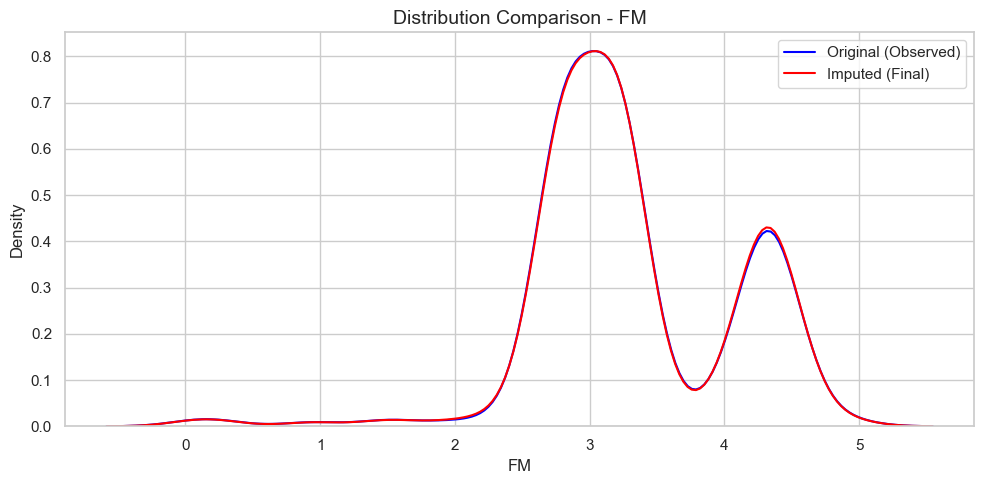

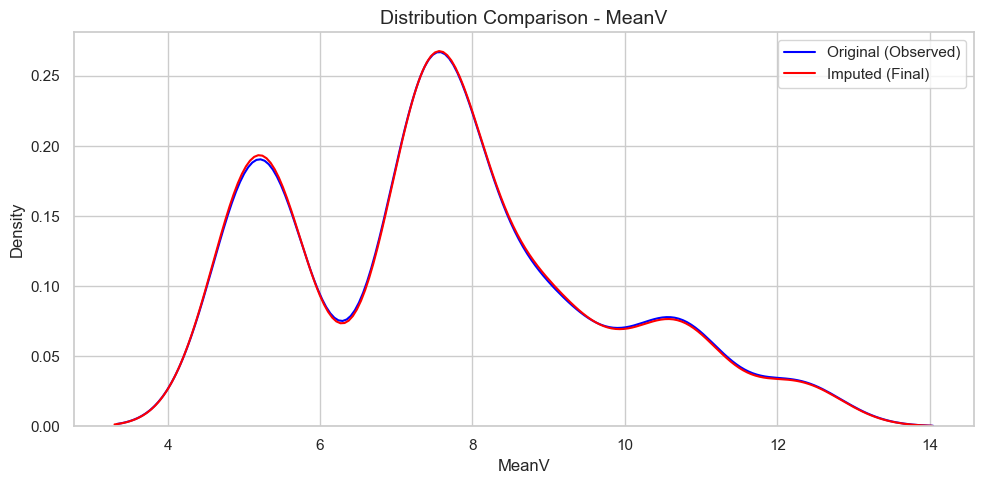

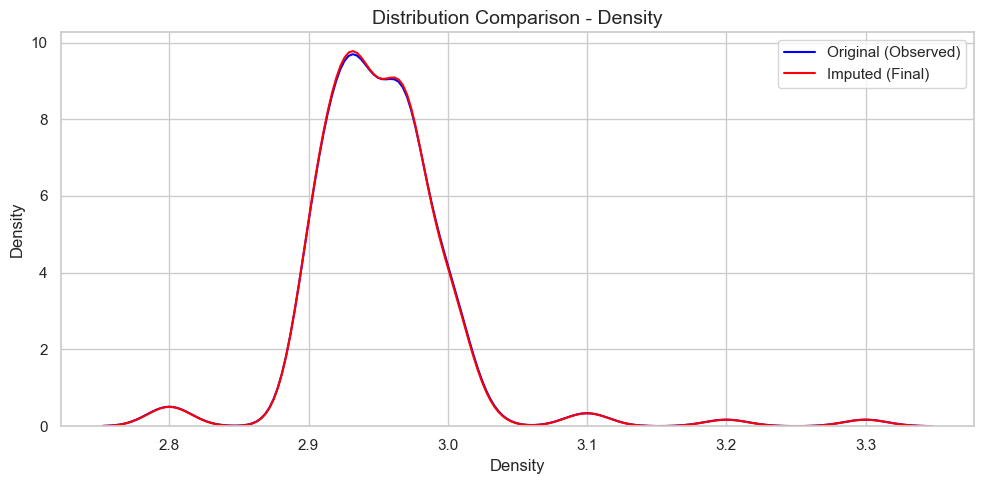

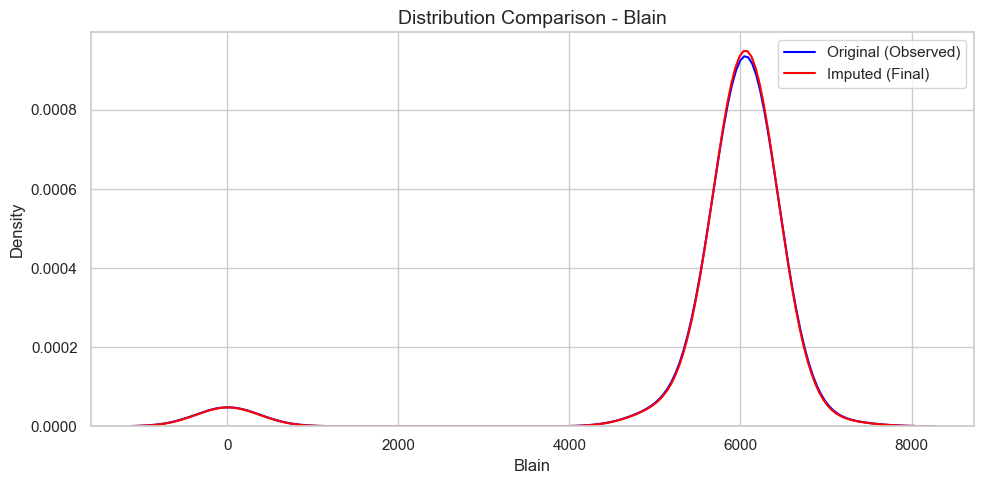

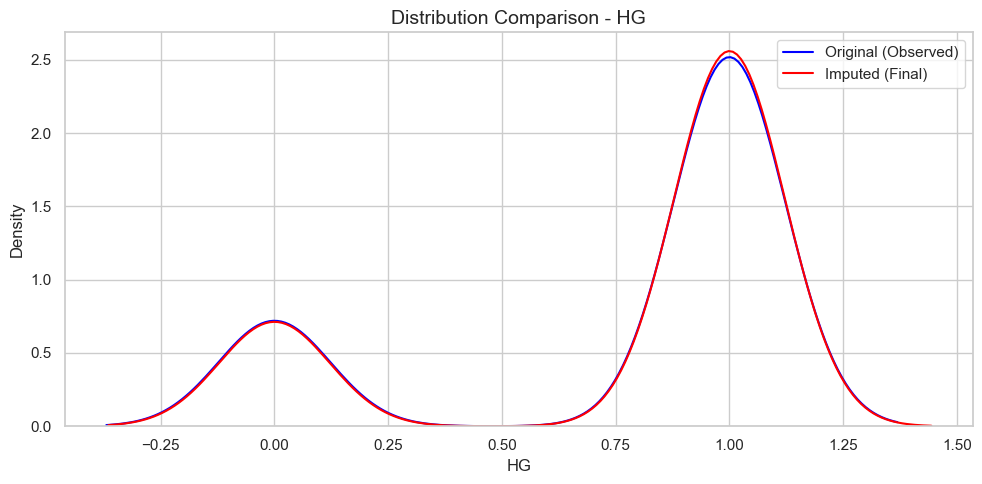

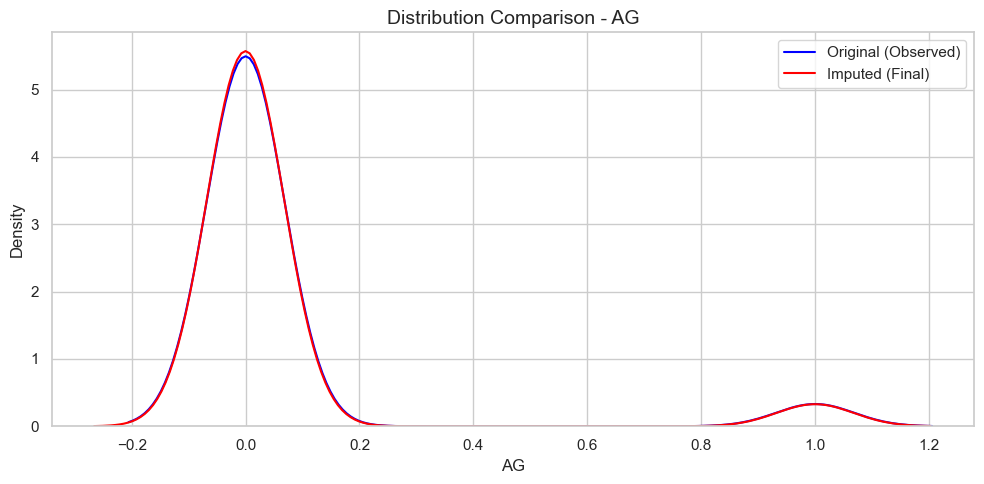

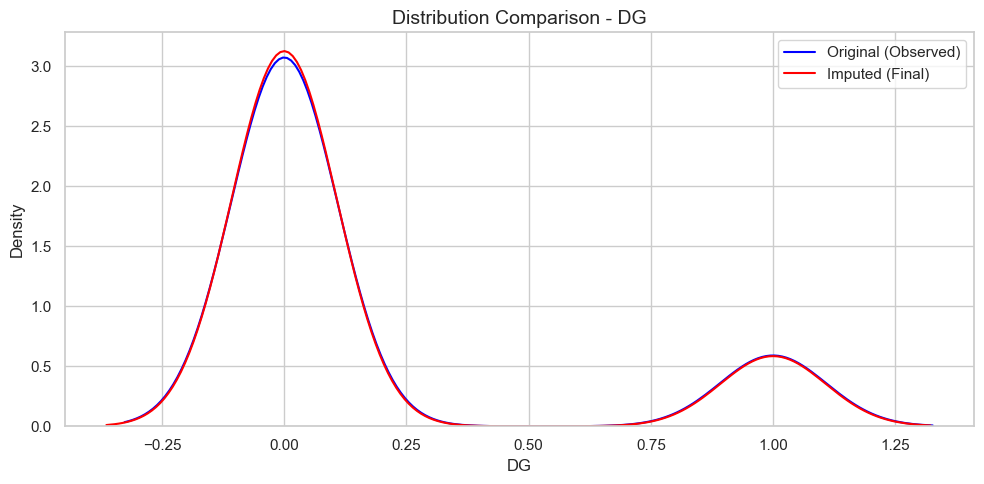

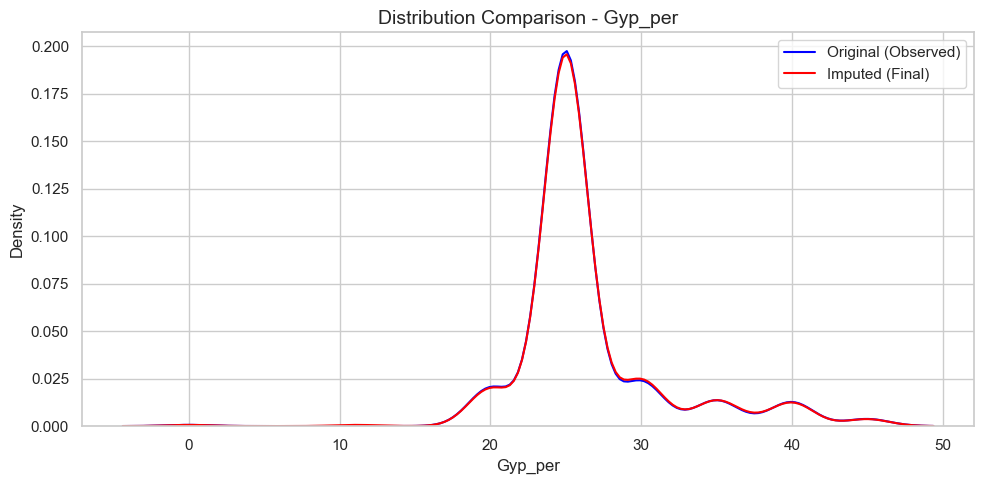

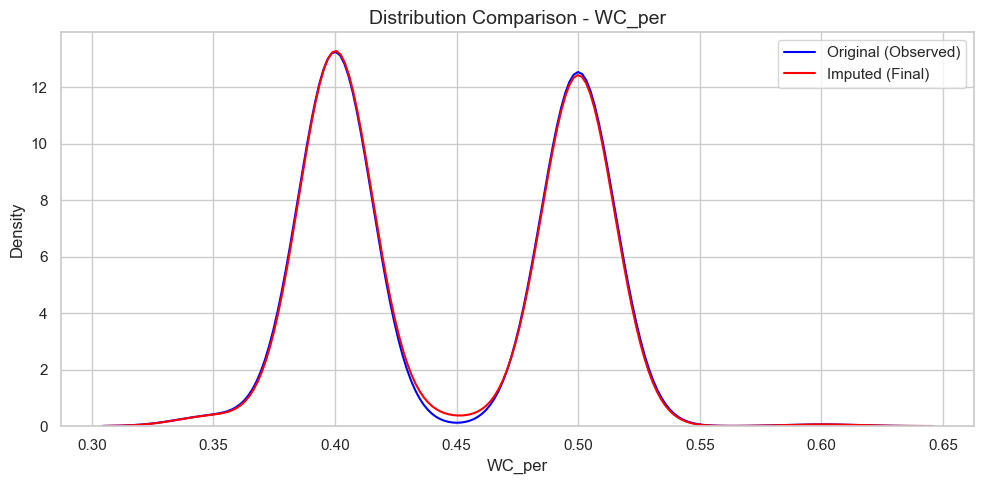

In [33]:
import matplotlib.pyplot as plt
import seaborn as sns

# 스타일 지정 (선택)
sns.set(style='whitegrid')

# 모든 타겟 컬럼에 대해 반복 시각화
for col in target_cols:
    plt.figure(figsize=(10, 5))
    
    # ① 결측치였던 값들 (예측값)
    imputed_idx = original_nan_idx[col]
    imputed_values = result_df.loc[imputed_idx, col]
    
    # ② 원래 결측치가 없던 값들
    observed_values = label_data.loc[:, col].dropna().drop(index=imputed_idx)

    # ③ 최종 전체 결과값 (결측치 대체 포함)
    final_values = result_df[col]

    # KDE or histogram
    sns.kdeplot(observed_values, label='Original (Observed)', color='blue')
    sns.kdeplot(final_values, label='Imputed (Final)', color='red')
    # sns.kdeplot(imputed_values, label='Predicted (Imputed)', color='green', linestyle='--')


    plt.title(f'Distribution Comparison - {col}', fontsize=14)
    plt.xlabel(col)
    plt.ylabel('Density')
    plt.legend()
    plt.tight_layout()
    plt.show()